# Demo for Bi-fidelity Stochastic Subspace Descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from configs.configs import *

def plot_results(
        file, 
        bf_ratio=0.0, 
        title='Results', 
        methods=None,
        index=None):
    plt.figure(figsize=(8,5))
    min_len = min(len(file['res'].item()[k][0]) for k in methods)
    if methods is None: methods = list(colors.keys())
    if index is None: index = 0

    for k in methods:
        color = colors[k]
        min_res = np.minimum.accumulate(file['res'].item()[k], axis=1)
        res_mean = np.mean(min_res, axis=0)
        res_best, res_worst = np.min(min_res, axis=0), np.max(min_res, axis=0)
        leng = len(res_mean)
        min_len = min(min_len, leng)
        t = np.arange(len(res_mean))
        if k == 'ssd_bf':
            t = (1 + bf_ratio) * t
        plt.plot(t[index:min_len], res_mean[index:min_len], label=names[k], color=color, lw=3.0, alpha=0.6)
        plt.fill_between(t[index:min_len], res_best[index:min_len], res_worst[index:min_len], alpha=0.4, color=color)
    plt.yscale('log')
    plt.xlabel('Equivalent HF Function Calls', fontsize=14), plt.ylabel('HF Function value', fontsize=14), plt.legend()
    plt.title(title, fontsize=20)
    plt.xlim(index, min_len)
    plt.tight_layout()

## Section 4.1 Worst Function in the World

We use an example function 
$$f(x; r) = \lambda ((x_1^2 + x_r^2 + \sum_{i=1}^{r-1}(x_i - x_{i+1})^2)/2 - x_1)/4.$$

We set $\lambda =20$, HF function $f(x;100)$ and LF function $f(x;2)$.

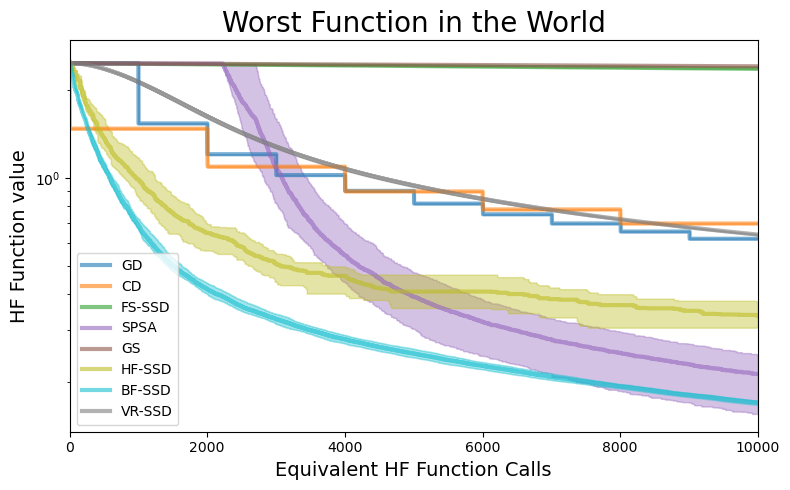

In [2]:
d = 1000
r1 = 100
r2 = 2
lmda = 20.0
ell = 10
c = 0.9
linesearch_iter = 10
num_iterations = 30
bf_ratio = linesearch_iter * r2 / ((ell + 1) * r1)

path = f'results/worst/worst-d{d}-rH{r1}-rL{r2}-lmda{lmda}-ell{ell}-c{c}.npz'
file = np.load(path, allow_pickle=True)

methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_hf', 'ssd_bf', 'ssd_sag']
plot_results(file, bf_ratio=bf_ratio, title='Worst Function in the World', methods=methods)

## Section 4.2.1 Black-box Kernel Ridge Regression

We use dual form of the kernel ridge regression 
$$f(\mathbf{\boldsymbol{\alpha}}; \tau, \mathbf{K}, \mathbf{y}) = \mathbf{\boldsymbol{\alpha}}^T\mathbf{K}\mathbf{\boldsymbol{\alpha}} - 2\langle \mathbf{\boldsymbol{\alpha}},\mathbf{y}\rangle + \lambda\lVert \mathbf{\boldsymbol{\alpha}}\rVert^2.$$
We set $\lambda = 1\times 10^{-3}$, LF function with kernel matrix approximated by Nystroem method. The optimal solution for this optimization is 
$$\mathbf{\alpha}^* = (\mathbf{K}+\lambda\mathbf{I})^{-1}\mathbf{y}.$$
We choose $D = 1000$ and $l = 10$ for Nystroem approximation.

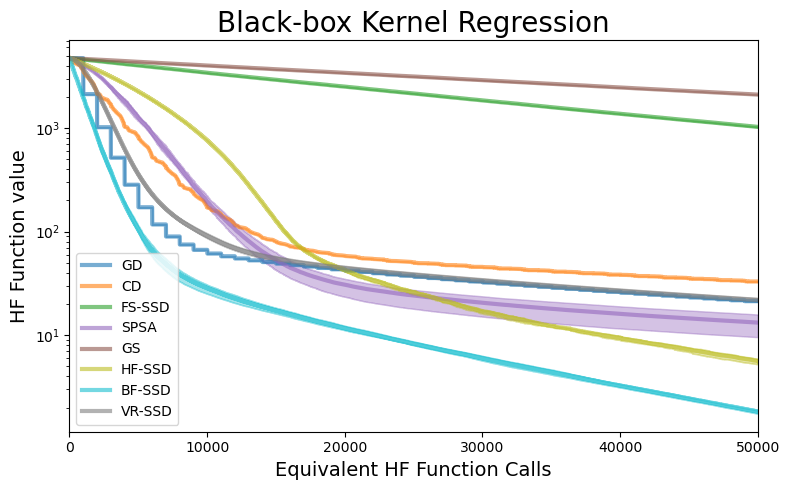

In [3]:
d = 1000
lr = 10
lmda = 20.0
L0 = 1.0
tau = 0.001
ell = 50
c = 0.95

path = f'results/kernel/kernel-d{d}-lr{lr}-L0{L0}-tau{tau}-ell{ell}-c{c}.npz'
file = np.load(path, allow_pickle=True)
bf_ratio = file['bf_ratio']

plot_results(file, bf_ratio=bf_ratio, title='Black-box Kernel Regression', methods=methods)

## Section 4.2.2 Black-box Adversarial Attack on MNIST Dataset

We consider the case of adversarial attack with black box model 
$$f(\mathbf{\delta}; y^\dagger, \mathbf{x}^\dagger, g) = -\text{CE}(g(\mathbf{x}+\mathbf{x}^\dagger), {y^\dagger}) + \lambda\lVert \mathbf{x}\rVert^2.$$
We set $\tau = 1\times 10^{-4}$, $\mathbf{x}^\dagger, y^\dagger$ as the first test sample, $g(\cdot)$ is a pre-trained CNN with test accuracy $99.02\%$. The low-fidelity model is a distilled CNN returns classification probability with accuracy $55.16\%$.

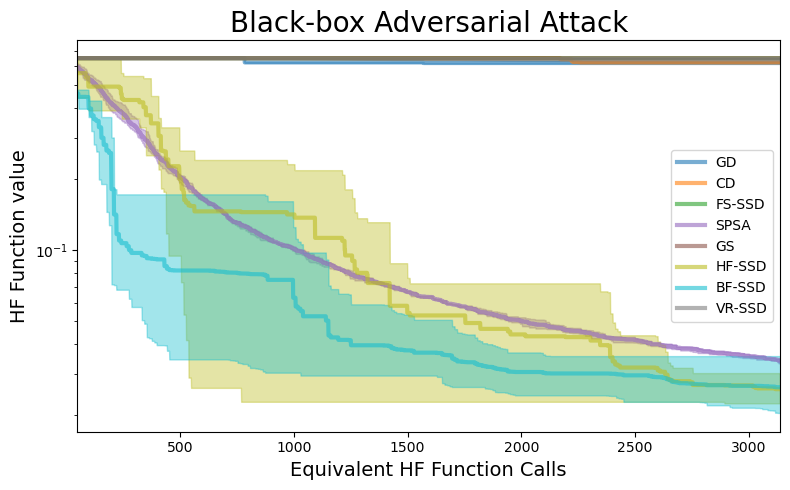

In [4]:
# Load results data
d = 784
tau = 1e-4
L0 = 2.5
ell = 10
c = 0.99
idx = 8

path = f'./results/adversarial/adversarial-d{d}-L0{L0}-tau{tau}-ell{ell}-c{c}-idx{idx}.npz'
file = np.load(path, allow_pickle=True)
bf_ratio = linesearch_iter / ((ell + 1) * 118.8)

plot_results(file, bf_ratio=bf_ratio, title='Black-box Adversarial Attack', methods=methods, index=50)

## Section 4.2.3 Black-box Soft Prompting on DistBERT for Sentiment Analysis

We consider a black-box pre-trained language classifier $f_c:\mathbb{R}^{L_t \times 768} \to [0, 1]$, a pre-trained tokenizer $f_t:\textup{str} \to \mathbb{R}^{L_t \times 768}$, where \texttt{str} is any string of arbitrary length, and the sequence length $L_t$ is a positive integer up to 512 representing the length of the embedding. The goal  is to find a soft prompt $\mathbf{x}^\ast \in \mathbb{R}^{768}$ such that
\begin{equation}
\mathbf{x}^\ast = \arg\min_{\mathbf{x}} \mathbb{E}_{(\mathbf{z}, y)}\big[\text{CE}(f_c(\text{cat}[\mathbf{x}, f_t(\mathbf{z})]), y)\big],
\end{equation}
where $\textup{CE}(\cdot,\cdot)$ is the cross-entropy loss function, and the dataset $(\mathbf{z}, y) \in \texttt{str} \times \{0, 1\}$. 

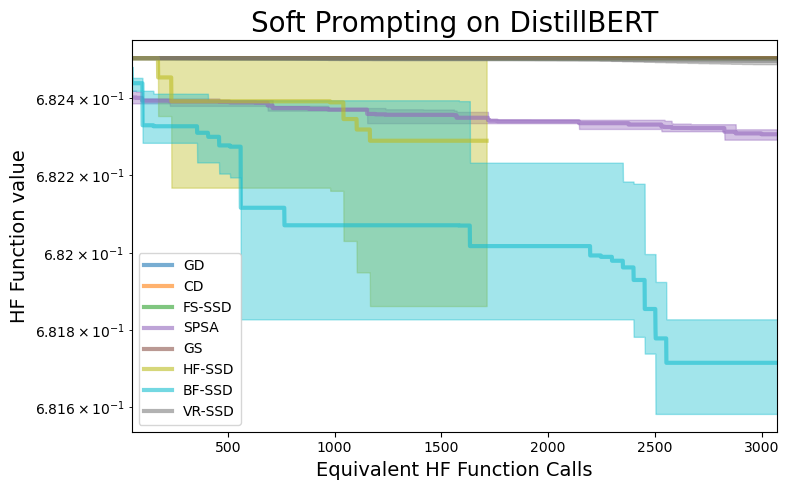

In [5]:
# Load results data
d = 768
L0 = 1.0
nH = 10
nL = 2
ell = 50
c = 0.999

path = f'./results/prompting/prompting-d{d}-L0{L0}-nH{nH}-nL{nL}-ell{ell}-c{c}.npz'
file = np.load(path, allow_pickle=True)
bf_ratio = linesearch_iter / ((ell + 1) * 100.0)

plot_results(file, bf_ratio=bf_ratio, title='Soft Prompting on DistillBERT', methods=methods, index=50)